## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ekamjot Singh

**Date:** 9/30/26

1. Regression predicts numerical quantity like price or height and then the classsifcation predicts that category. Like they are stored as class labels and the problem needs classifcation and averaging the labels would not give a meanigful type.

2. A confusion table predcits like couunts or figures out for each actual class combination. Like the rows are actual classes and the columns are the predicted adn the diagonal has the correct predictions. It shows which types are confused with another and when the overal accuracy is good

3. The sum of squared errors measures the total difference between the actual and predicted and the larger errors receive more weight because they are squared and a smaller SSe on the same evaluations means you would have a better prediction SSE depends on the number of units and like observations.

4. overfitting means a model follows training spefic patterns to closley like its good on the training data but not good at finding new things. When we do KNN small k can overfit. Underfitting means the model is not good at finding strucutre or patterns and having a big k may underfit because the prediction averages across observations that are not the same

5. A split allows a model to be fit on one group of observations and it did not use for fifting and compares the values of k using validation for the classifcation and can help select a model that generalizes it better than instead using lilke one training performance

6. A predicted class label is like simple to figure out and works well when an application needs a category and the bad thing about it is it hides the uncertaintiy. A distribution is used to show how everything is divided across the categories and figure out random predictions or things with error costs that are different.




    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
Rows and columns: (338, 4)
Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
Mine-type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Feature summaries:
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000
Mean features by mine type:
            voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          

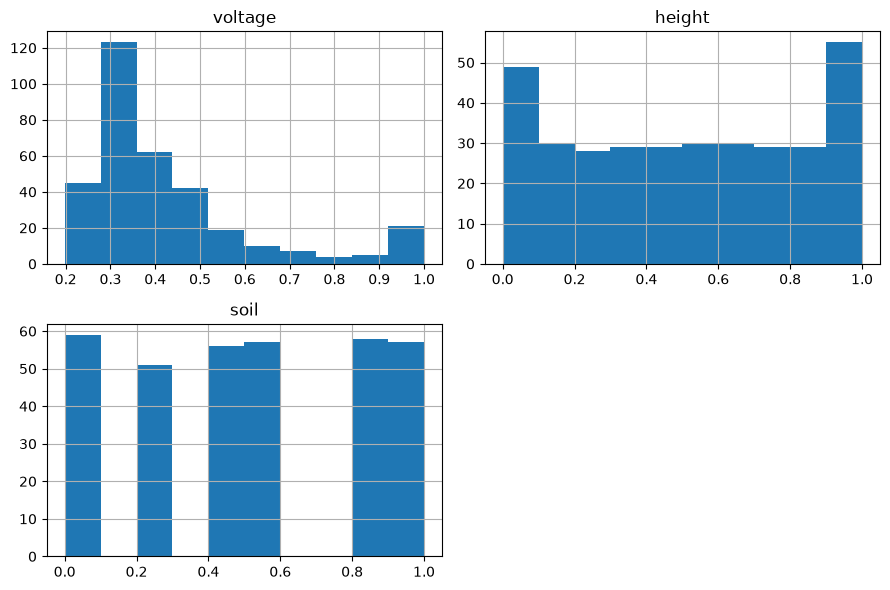

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix


df = pd.read_csv("data/land_mines.csv")
feature_names = ["voltage", "height", "soil"]
labels = [1, 2, 3, 4, 5]

print(df.head())
print("Rows and columns:", df.shape)
print("Missing values:")
print(df.isna().sum())
print("Mine-type counts:")
print(df["mine_type"].value_counts().sort_index())
print("Feature summaries:")
print(df[feature_names].describe())
print("Mean features by mine type:")
print(df.groupby("mine_type")[feature_names].mean())

# show the  histogram
df[feature_names].hist(figsize=(9, 6))
plt.tight_layout()
plt.show()


2.1 the supplied data has around 338 observation and 3 numerical features and the category for the target. It has voltage, height, and soil. There are no missing values or duplicates. Voltage ranges from 0.20 to 1 with a mean around 0.43 and type 2 has higher voltage around 0.72. I thinkn that their averages are same across mayn classes but this doesn't tell us how accruacte the model will be.

Training observations: 169
Validation observations: 169
Best k: 1


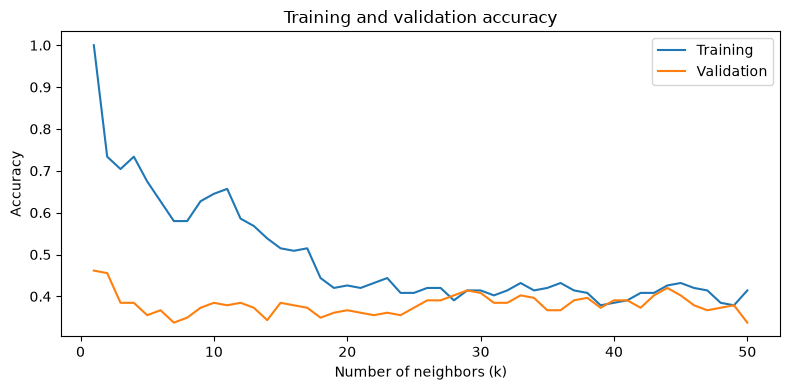

In [48]:
# Select the target and features
X = df[feature_names]
y = df["mine_type"]

# split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)
print("Training observations:", len(X_train))
print("Validation observations:", len(X_valid))

# fit the sclar on the training 
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# compare k values
k_values = np.arange(1, 51)
training_accuracy = []
validation_accuracy = []

for k in k_values:
    candidate = KNeighborsClassifier(n_neighbors=int(k))
    candidate.fit(X_train_scaled, y_train)
    train_pred = candidate.predict(X_train_scaled)
    valid_pred = candidate.predict(X_valid_scaled)
    training_accuracy.append(np.mean(train_pred == y_train))
    validation_accuracy.append(np.mean(valid_pred == y_valid))

# chose best modell
best_k = int(k_values[np.argmax(validation_accuracy)])
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_valid_scaled)
print("Best k:", best_k)

plt.figure(figsize=(8, 4))
plt.plot(k_values, training_accuracy, label="Training")
plt.plot(k_values, validation_accuracy, label="Validation")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()


I split it half and half. The split helps the class mix the asme in both and made it repeate as well as scale the features only using the training data and applied the same scaling to validate. I think this is important because the nearest neighbors comprae distances and features with bigger ranges would actually count for more also voltage has a smaller range than other. I tried k from 1-50 and pikced the one with the best accruacy and if they tied i just picked the smaller k. I got k = 1 being the best choice to split but i wouldn't say its the best in general

In [49]:

cm = confusion_matrix(y_valid, y_pred, labels=labels)
confusion_table = pd.DataFrame(cm, index=labels, columns=labels)
confusion_table.index.name = "Actual"
confusion_table.columns.name = "Predicted"
print(confusion_table)

# show accuracy in fraction
correct = np.sum(y_pred == y_valid)
accuracy = correct / len(y_valid)
print("Correct predictions:", correct, "out of", len(y_valid))
print("Validation accuracy:", round(100 * accuracy, 2), "%")


Predicted   1   2  3   4  5
Actual                     
1          21   0  4   4  7
2           0  32  0   3  0
3           8   0  7  10  8
4           7   5  4  11  6
5           7   0  9   9  7
Correct predictions: 78 out of 169
Validation accuracy: 46.15 %


The model got 78/169 which was 46.15 and made around 91 mistakes. I thik that type 2 perofmed the best because it had 32/35 right and type 1 had 21/36 and types 3,4,5 were harder because they were mixed up.

I would like to use this model to help like trained expert with more inspection and it makes a lot of mistakes so like i would not rely on it alone with making decisions or figuring out if a certain area is safe. But for real worl it needs mot testing and observations.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 35c08ed2f0dc2acab4b46e85f95b8c5616f6a430
- **AI tool and model used:** Gpt 6.1 Sol

### *Prompts used

1. What reivions can I add to my assingment
2. Bsedies spelling errors

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]
1.Q1.3: Clearly define SSE as the sum of squared differences between actual and predicted values.
2.Q1.6: Add that probabilities show uncertainty, but can be harder to interpret and can still be wrong.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Makes it more precise I think and cleans up my defintion |
| 2 | Accept  | Adds the weakness which I did not add and a class with the highest probabiltiy can still be wrong |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

1.3 SSE is the sum of the squared differences between actual and predicted values. Larger errors count more because they are squared. When comparing models on the same data, a smaller SSE means better predictions.

1.6 A class label gives one prediction and is easy to use, but it hides uncertainty. A probability distribution gives a probability for each class and shows other possible predictions. However, probabilities can be harder to interpret, and a high probability does not guarantee a correct prediction.

### *Reflection on AI assistance
In your own words without generative AI.

I would say that in phase 2 I had used to imrpove mostly my explanations in the phase 1 of the assignemnt. the first change was explaining the SSe wrong, my orignal talked about differneces in acutal nad prediction but didn't talk about squaring or ading. It also explains to me why the larger erros do count more. We also added was class labels and probabilties and talked about the class label is simple but hides unertainty. The revising adds that some probabilties can be harder to fiure out and that a high one doesn't mean its correct. Ai initially just suggested fixing my spelling erros, but I moslty wanted to see what actually needed to be cleaned up. The SSE explantion can be checked using the erros of 1/2 giving SSE of 5. I think a big concern of mine woulld be that the model makes alot of mistakes and it should only be worked with by experts and not someone who is acutally trying to use it. 

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]